# Vigilant allocation: a strong winner can coexist with weak breadth

**Constructed educational scenarios; not a historical VAA replication.** With a breadth threshold of one, a single weak risky asset switches the example from its strongest risky holding to its strongest defensive holding. The winner need not change for total exposure to change.

[Chapter narrative](README.md) · [Research collection](../../README.md)

## Goal

Trace price momentum into breadth, ranking and portfolio weights. The strategy attribution is Keller and Keuning, [*Breadth Momentum and Vigilant Asset Allocation* (2017)](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=3002624). This notebook renews the original repository's `06_vigilant_asset_allocation_with_momentum.ipynb` topic using a deliberately small, transparent illustration.

## Setup

Four fictional risky assets and two fictional defensive assets have twelve constructed monthly returns. Three scenarios differ only in their final return. Month numbers are scenario steps. Prices are positive cumulative levels starting at 100, without external downloads, missing-price filling or original vendor inputs.

The primary illustration uses one risky slot and breadth threshold $B=1$. Cash is a name for the protective allocation in the literature; here it is explicitly invested in the strongest of two constructed defensive price paths and is not guaranteed to preserve capital.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display

plt.rcParams.update({
    'figure.figsize': (10, 4.6), 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.18,
    'axes.axisbelow': True, 'figure.dpi': 120,
})
BLUE, GOLD, GRAY = '#245a81', '#bc8431', '#606975'
# All prices are constructed inside this notebook; there are no downloads.

In [2]:
risky = ['US equity', 'Developed equity', 'Emerging equity', 'Aggregate bond']
defensive = ['Bills', 'Treasury']
assets = risky + defensive
base_return = np.array([0.018, 0.014, 0.012, 0.004, 0.002, 0.003])
monthly_scenarios = {}
for name in ['Broadly positive', 'One weak asset', 'Broad weakness']:
    monthly_scenarios[name] = pd.DataFrame(np.tile(base_return, (12, 1)), columns=assets)
monthly_scenarios['One weak asset'].loc[11, 'Emerging equity'] = -0.06
monthly_scenarios['Broad weakness'].loc[11, risky] = [-0.08, -0.07, -0.06, -0.025]
display(pd.DataFrame({name: returns.iloc[-1] for name, returns in monthly_scenarios.items()})
        .style.format('{:.1%}'))

,Broadly positive,One weak asset,Broad weakness
US equity,1.8%,1.8%,-8.0%
Developed equity,1.4%,1.4%,-7.0%
Emerging equity,1.2%,-6.0%,-6.0%
Aggregate bond,0.4%,0.4%,-2.5%
Bills,0.2%,0.2%,0.2%
Treasury,0.3%,0.3%,0.3%


## Steps

### 1. Measure returns from prices at four horizons

Use the unscaled composite $12R_1+4R_3+2R_6+R_{12}$. The score is not an annual-return estimate. These are monthly observations, so a lag of 12 means twelve complete intervals, requiring thirteen prices.

In [3]:
def weighted_momentum(path, information_month=12):
    history = path.loc[:information_month]
    if len(history) < 13 or history.isna().any().any():
        raise ValueError('Need thirteen complete monthly price observations.')
    if not np.isfinite(history.to_numpy()).all() or (history <= 0).any().any():
        raise ValueError('Prices must be finite and positive.')
    current = history.iloc[-1]
    return sum(weight * (current / history.iloc[-1 - lag] - 1)
               for lag, weight in [(1, 12), (3, 4), (6, 2), (12, 1)])

def constructed_path(monthly_returns):
    monthly_returns = pd.DataFrame(monthly_returns)
    levels = np.vstack([np.ones(monthly_returns.shape[1]),
                        np.cumprod(1 + monthly_returns.to_numpy(), axis=0)])
    return pd.DataFrame(100 * levels, columns=monthly_returns.columns,
                        index=pd.Index(range(len(levels)), name='Constructed month'))

In [4]:
paths = {name: constructed_path(returns) for name, returns in monthly_scenarios.items()}
scores = pd.DataFrame({name: weighted_momentum(path) for name, path in paths.items()}).T
display(scores.round(4))

,US equity,Developed equity,Emerging equity,Aggregate bond,Bills,Treasury
Broadly positive,0.9006,0.6939,0.5920,0.1937,0.0964,0.145
One weak asset,0.9006,0.6939,-0.8019,0.1937,0.0964,0.145
Broad weakness,-1.0152,-0.9375,-0.8019,-0.3607,0.0964,0.145


### 2. Count weak risky assets and select holdings

Let $b$ count risky scores less than or equal to zero. The simplified defensive fraction is $\min(1,b/B)$. The remaining budget goes to the strongest risky asset, and the defensive budget to the strongest defensive asset. Exact ties use alphabetical order. Fractional exposure with $B=2$ is a teaching comparison, not a claim about all published VAA rounding conventions.

In [5]:
def top_name(values):
    return values.sort_index().sort_values(ascending=False, kind='stable').index[0]

def vaa_style_weights(score, breadth_threshold=1):
    if breadth_threshold <= 0:
        raise ValueError('Breadth threshold must be positive.')
    bad_count = int((score.loc[risky] <= 0).sum())
    defensive_fraction = min(1.0, bad_count / breadth_threshold)
    target = pd.Series(0.0, index=assets)
    target[top_name(score.loc[risky])] = 1 - defensive_fraction
    target[top_name(score.loc[defensive])] = defensive_fraction
    return target, bad_count

targets = pd.DataFrame({name: vaa_style_weights(row)[0] for name, row in scores.iterrows()}).T
decisions = pd.DataFrame({
    'Weak risky assets': (scores[risky] <= 0).sum(axis=1),
    'Defensive fraction, B=1': targets[defensive].sum(axis=1),
    'Defensive fraction, B=2': [vaa_style_weights(row, 2)[0][defensive].sum()
                               for _, row in scores.iterrows()],
})
display(decisions)
display(targets.style.format('{:.0%}'))

,Weak risky assets,"Defensive fraction, B=1","Defensive fraction, B=2"
Broadly positive,0,0.0,0.0
One weak asset,1,1.0,0.5
Broad weakness,4,1.0,1.0


,US equity,Developed equity,Emerging equity,Aggregate bond,Bills,Treasury
Broadly positive,100%,0%,0%,0%,0%,0%
One weak asset,0%,0%,0%,0%,0%,100%
Broad weakness,0%,0%,0%,0%,0%,100%


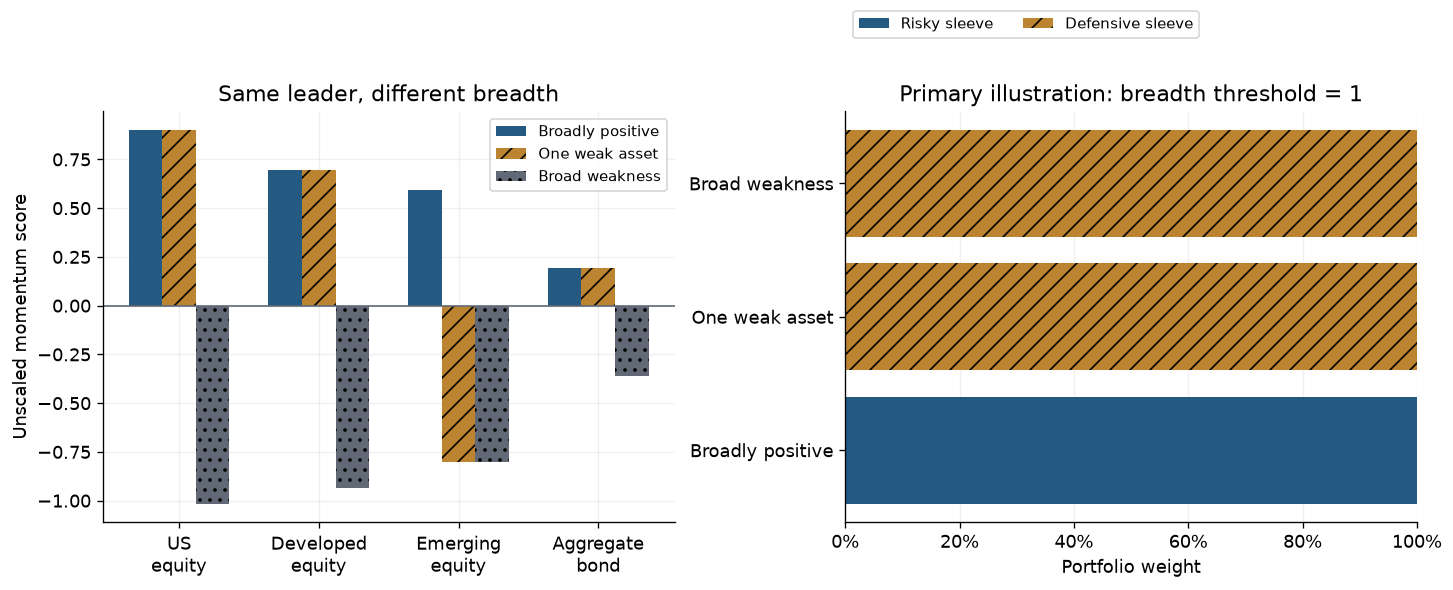

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), layout='constrained')
x = np.arange(len(risky))
for j, (name, row) in enumerate(scores.iterrows()):
    axes[0].bar(x + (j - 1) * 0.24, row[risky], 0.24,
                color=[BLUE, GOLD, GRAY][j], label=name, hatch=['', '//', '..'][j])
axes[0].axhline(0, color=GRAY, linewidth=1)
axes[0].set(xticks=x, xticklabels=['US\nequity', 'Developed\nequity', 'Emerging\nequity', 'Aggregate\nbond'],
            ylabel='Unscaled momentum score', title='Same leader, different breadth')
axes[0].legend(fontsize=9)
risky_fraction = targets[risky].sum(axis=1)
axes[1].barh(targets.index, risky_fraction, color=BLUE, label='Risky sleeve')
axes[1].barh(targets.index, 1 - risky_fraction, left=risky_fraction,
            color=GOLD, hatch='//', label='Defensive sleeve')
axes[1].set(xlim=(0, 1), xlabel='Portfolio weight', title='Primary illustration: breadth threshold = 1')
axes[1].xaxis.set_major_formatter(PercentFormatter(1))
axes[1].legend(loc='lower left', bbox_to_anchor=(0, 1.16), fontsize=9, ncol=2)
plt.show()

A weak Emerging equity score changes the primary example's defensive allocation from 0% to 100%, although the US equity path is unchanged. The breadth rule monitors the whole risky universe. With the threshold doubled, that same one-asset deterioration produces 50% defense.

## Checks

A 1%-per-month path has a directly calculable score. A flat path has exactly zero momentum and therefore counts as weak. Signals use data through their information date, and the timing illustration assigns ownership only after a later execution close.

In [7]:
constant_growth = pd.DataFrame({'Known path': 100 * 1.01 ** np.arange(13)})
known_score = 12 * 0.01 + 4 * (1.01**3 - 1) + 2 * (1.01**6 - 1) + (1.01**12 - 1)
np.testing.assert_allclose(weighted_momentum(constant_growth).iloc[0], known_score)
flat = pd.DataFrame(np.ones((13, len(assets))) * 100, columns=assets)
assert vaa_style_weights(weighted_momentum(flat))[1] == 4
assert decisions['Weak risky assets'].tolist() == [0, 1, 4]
np.testing.assert_allclose(decisions['Defensive fraction, B=2'], [0, 0.5, 1])
np.testing.assert_allclose(targets.sum(axis=1), 1)
assert (targets >= 0).all().all()
extended = paths['Broadly positive'].copy()
extended.loc[13] = extended.loc[12] * np.array([0.2, 3, 0.5, 2, 0.8, 1.1])
pd.testing.assert_series_equal(weighted_momentum(extended, 12), scores.loc['Broadly positive'], check_names=False)
broken = paths['Broadly positive'].copy()
broken.loc[3, 'US equity'] = np.nan
try:
    weighted_momentum(broken)
except ValueError:
    pass
else:
    raise AssertionError('Missing prices must not become zero returns.')
timing = pd.DataFrame({'Information close': [12], 'Execution close': [13], 'First earned return ends': [14]})
assert timing.iloc[0, 0] < timing.iloc[0, 1] < timing.iloc[0, 2]
display(timing)
print('Passed: independent formula, zero threshold, breadth response, budgets, missing-data rejection and timing.')

,Information close,Execution close,First earned return ends
0,12,13,14


Passed: independent formula, zero threshold, breadth response, budgets, missing-data rejection and timing.


## Next steps

Investigate how universe choice, breadth threshold and execution lag affect turnover, missed recoveries and defensive-asset risk. No return advantage or crash-protection reliability is established by these constructed snapshots. A genuine replication must fix the paper variant, instruments or documented proxies, distribution adjustments, calendar, selection rounding, costs and sample before measuring results.

[DAA's separate canary universe](../08-defensive-allocation/README.md) changes the information used for the exposure decision while retaining relative-momentum selection.